# BW \#104 Aviation accidents
So this week, we'll look at aviation accidents, to see when and where they take place, and if the numbers have indeed changed over time. 

## Data and six questions
The data comes from two CSV files based on the "aviation investigation search" page (https://www.ntsb.gov/Pages/AviationQueryV2.aspx).

## Challenges
The learning goals memory optimization, working with dates and times, plotting, and string manipulation.

- Create a df from the CSV file. Make sure hat `EventDate`  is treated as a `datetime` value. How much memory can you save by adjusting the dtypes from the defaults ?

- Display a bar graph showing for 5 year period in our data set, the number of flights in the US with fatalities. Do we see a trend ?

### Create a df from the CSV file. Make sure hat `EventDate`  is treated as a `datetime` value. How much memory can you save by adjusting the dtypes from the defaults ?


In [1]:
import pandas as pd

In [14]:
filename = r"C:\Users\npigeon1\Pandas-Bamboo-Weekly\BW #104 Aviation accidents\b3aa5615-8caf-4361-b2f6-54a91a98c447AviationData.csv"
df = pd.read_csv(filename, 
                 )
df.info()

C:\Users\npigeon1\AppData\Local\Temp\ipykernel_13340\2327045431.py:2: DtypeWarning: Columns (16,17,23,27,35,36) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filename,


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177194 entries, 0 to 177193
Data columns (total 38 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   NtsbNo               177194 non-null  object 
 1   EventType            177147 non-null  object 
 2   Mkey                 177194 non-null  int64  
 3   EventDate            177170 non-null  object 
 4   City                 177116 non-null  object 
 5   State                167675 non-null  object 
 6   Country              176667 non-null  object 
 7   ReportNo             377 non-null     object 
 8   N                    177074 non-null  object 
 9   HasSafetyRec         177194 non-null  bool   
 10  ReportType           169913 non-null  object 
 11  OriginalPublishDate  156945 non-null  object 
 12  HighestInjuryLevel   72165 non-null   object 
 13  FatalInjuryCount     177194 non-null  int64  
 14  SeriousInjuryCount   177194 non-null  int64  
 15  MinorInjuryCount 

Remember that CSV is a text-based format. This means that when Pandas loads a CSV file into a data frame, it tries to determine whether each column should be `int64`, `float64`, or `object` – the last of which basically means a string type. But it doesn't load the entire file at once, which means that its determination can be different for different parts of the file. 

The warning tells us that we can fix this in a two ways: We can pass `low_memory=False` to `pd.read_csv`, allowing the entire file to be read into memory in a single chunk. We can also pass the `dtype` keyword argument, specifying what types we want for the columns we read. 

But there is a third option, one which Pandas doesn't name: We can use PyArrow to load the CSV file. They are often dramatically faster than the native Pandas CSV loader, and as a nice bonus, recognize and handle datetime values, too, without needing to pass the parse_dates keyword argument. Finally, PyArrow doesn't suffer from the issues that the Pandas CSV parser does with large files.

In [16]:
df = pd.read_csv(filename, engine='pyarrow')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177194 entries, 0 to 177193
Data columns (total 38 columns):
 #   Column               Non-Null Count   Dtype             
---  ------               --------------   -----             
 0   NtsbNo               177194 non-null  object            
 1   EventType            177147 non-null  object            
 2   Mkey                 177194 non-null  int64             
 3   EventDate            177170 non-null  datetime64[s, UTC]
 4   City                 177116 non-null  object            
 5   State                167675 non-null  object            
 6   Country              176667 non-null  object            
 7   ReportNo             377 non-null     object            
 8   N                    177074 non-null  object            
 9   HasSafetyRec         177194 non-null  bool              
 10  ReportType           169913 non-null  object            
 11  OriginalPublishDate  156945 non-null  datetime64[s, UTC]
 12  HighestInjuryLev

We can calculate and display the amount of memory used by df by invoking memory_usage on our data frame.

However, if we simply invoke memory_usage, we won't get the true usage. That's because our strings are stored in Python's memory, not in the NumPy backend that Pandas uses. 

We thus pass deep=True to memory_usage, and then invoke sum on the resulting series

In [19]:
before_memory = df.memory_usage(deep=True).sum()
print(f'{before_memory=:,}')

before_memory=250,195,480


One of the biggest wins in Pandas memory management is to use categories. If you have a string (object) column with values that repeat themselves, then switching to a category dtype can save you lots of memory. Basically, a category looks, feels, and acts the same as a string – but behind the scenes, it actually contains an integer, referring to the original string value in an array.

In [20]:
for one_column in df.select_dtypes('object').columns:
    print(f'\t{one_column}')
    df[one_column] = df[one_column].astype('category')

	NtsbNo
	EventType
	City
	State
	Country
	ReportNo
	N
	ReportType
	HighestInjuryLevel
	ProbableCause
	EventID
	Make
	Model
	AirCraftCategory
	AirportID
	AirportName
	AmateurBuilt
	NumberOfEngines
	Scheduled
	PurposeOfFlight
	FAR
	AirCraftDamage
	WeatherCondition
	Operator
	ReportStatus
	DocketUrl
	DocketPublishDate


However, there was one more set of columns that I decided to shrink: The three columns that count injuries and fatalities were defined as int64, when they never went higher than a few hundred. I decided to change those columns to uint16, meaning unsigned 16-bit integers

How can I choose the columns I want? I decided to invoke df.filter, which lets us select columns from a data frame via a regular expression. I asked for .*Count$, meaning that I wanted the column name to end with the string 'Count'. 

In [21]:
for one_column in df.filter(regex='.*Count$', axis='columns'):
    df[one_column] = df[one_column].astype('uint16')

In [22]:
after_memory = df.memory_usage(deep=True).sum()
print(f'{after_memory=:,}')

after_memory=87,732,489


In [23]:
print(f'{after_memory / before_memory=:0.2f}')

after_memory / before_memory=0.35


In other words: With a handful of lines of code, we managed to cut our memory usage down to 35 percent of its original size (about 87 MB), without reducing functionality.

The data frame contains 176,884 rows and 38 columns.

### Display a bar graph showing for 5 year period in our data set, the number of flights in the US with fatalities. Do we see a trend ?

First use loc and lambda to keep only those rows from the US. we only want those incidents in which there was at least one fatality

to look at every 5-year period in the data set. That'll require more than a simple groupby; that would work on each year, or even each month. We'll need to use resample, which only works on a time series – that is, when the index is a datetime. So we'll use set_index to move EventDate to the index, and then run resample with a period of 5YE

But wait, what do we want to calculate for every 5-year period? I asked you to find the number of flights with fatalities. That means counting the rows, which in turn means that we can choose any column and invoke count on it. I chose NtsbNo, the ID number for the NTSB investigation:

<Axes: xlabel='EventDate'>

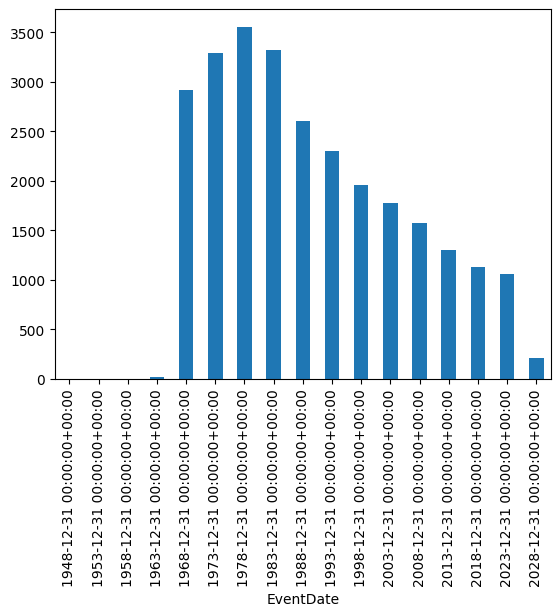

In [ ]:
(
    df
    .loc[lambda df_: df_['Country'] == 'United States']
    .loc[lambda df_: df_['FatalInjuryCount'] > 0]
    .set_index('EventDate')
    .resample('5YE')['NtsbNo'].count()
    .plot.bar()
)

The final bar is much shorter than the previous ones because it only reflects incidents through the end of 2024, only 20 percent of the other periods. But we otherwise do we a pretty clear downward trend, from a high of 3,500 flights with fatalities in the 1970s to 1,000 in the last decade.

The NTSB data set includes information about whether the flights were amateur or commercial, and it would certainly be interesting to find how many of the problematic flights were amateur, given how many commentators mentioned that the DC flight was the first fatality of a commercial airliner in more than a decade.

